# Packages

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib import pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.facecolor'] = 'white'

# Read Data

In [2]:
df0 = pd.read_csv("MethaneData.csv")

# Fig. 1 Analyses and Plot

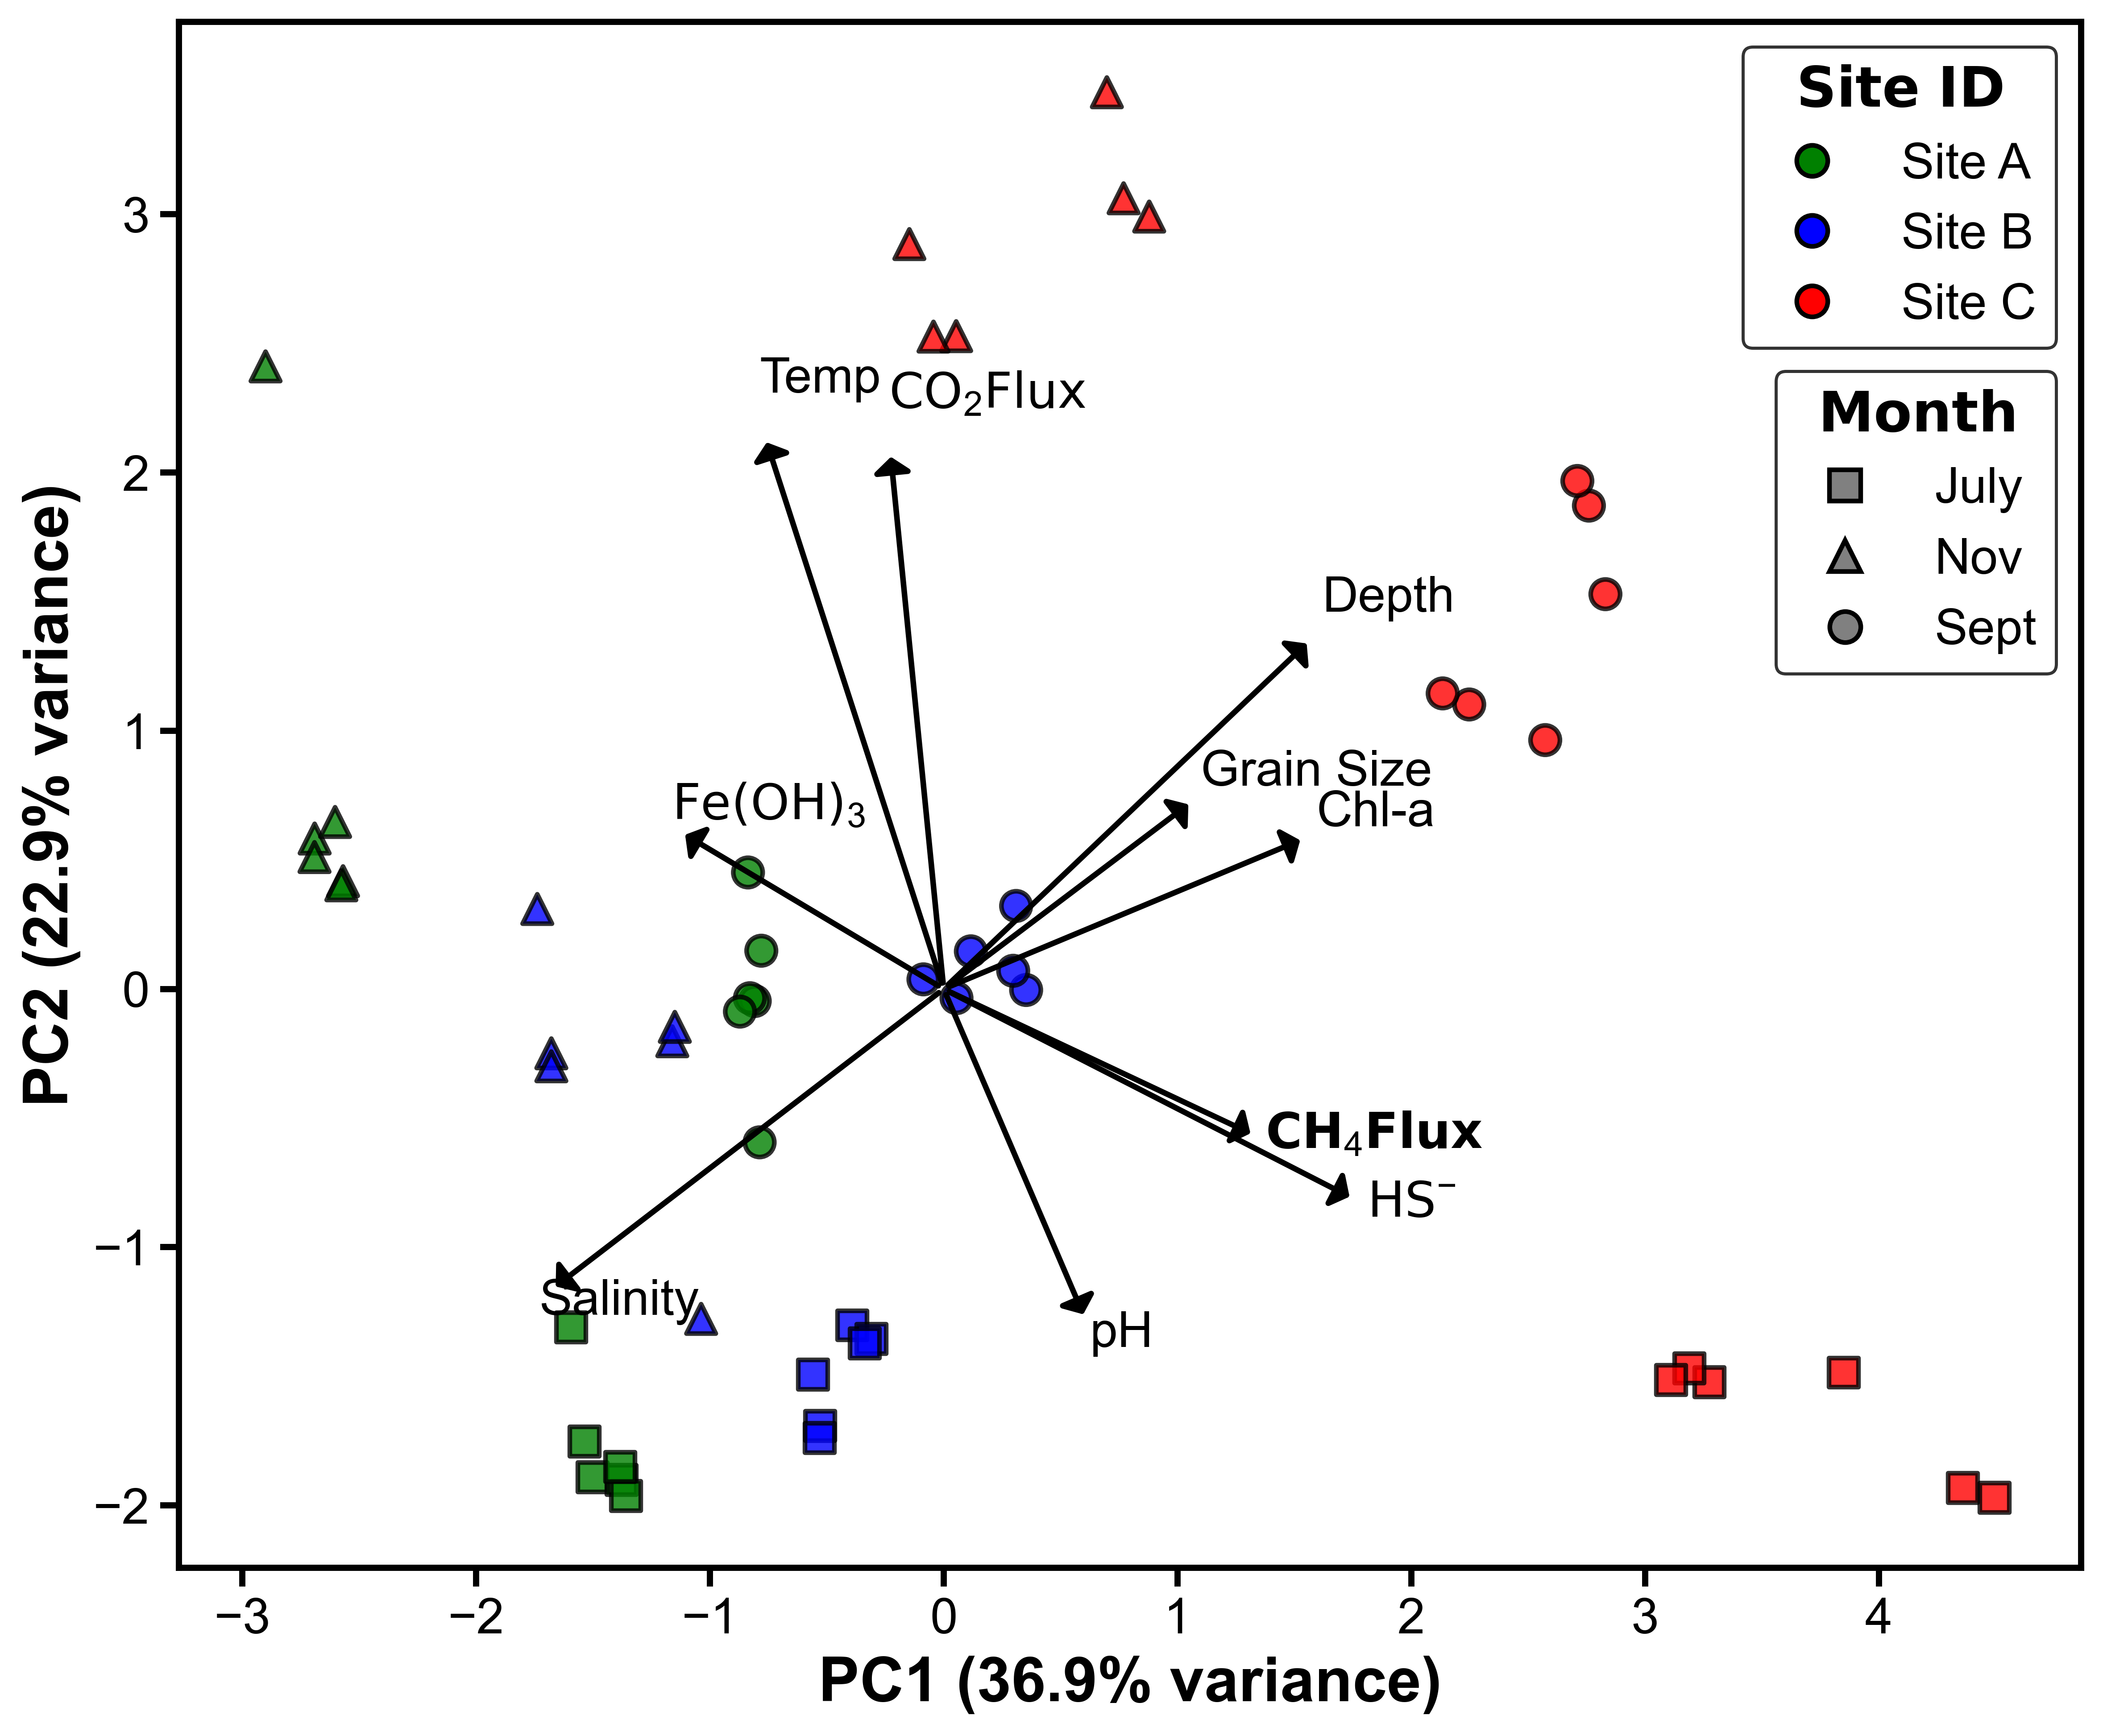

In [3]:
draft = True
df = df0.rename(columns={'CO2':'$\mathrm{CO_{\mathregular{2}} Flux}$',
                        'CH4':'$\mathbf{CH_{\mathregular{4}} Flux}$',
                        'Fe(OH)3':'$\mathrm{Fe(OH)_{\mathregular{3}}}$',
                        'HS-':'$\mathrm{HS^{\mathregular{-}}}$'})
df_num = df.iloc[:, 3:13]

scaler = StandardScaler()
df_num_scaled = scaler.fit_transform(df_num)
pca = PCA()
scores = pca.fit_transform(df_num_scaled)
loadings = pca.components_.T
var_ratios = pca.explained_variance_ratio_

pc1 = scores[:,0]
pc2 = scores[:,1]

sites_JUL = df[df['Month']=="JUL"]["Site"].astype(str)
sites_NOV = df[df['Month']=="NOV"]["Site"].astype(str)
sites_SEP = df[df['Month']=="SEP"]["Site"].astype(str)

colour_dict = {"A": "green", "B": "blue", "C": "red"}

fig, ax = plt.subplots(figsize=(11,9))
ax.scatter(pc1[df['Month']=="JUL"], pc2[df['Month']=="JUL"],
           color=[colour_dict[i] for i in sites_JUL],
           s=90, marker='s', linewidths=1.5, edgecolors='black', alpha=0.8)

ax.scatter(pc1[df['Month']=="NOV"], pc2[df['Month']=="NOV"],
           color=[colour_dict[i] for i in sites_NOV],
           s=90, marker='^', linewidths=1.5, edgecolors='black', alpha=0.8)

ax.scatter(pc1[df['Month']=="SEP"], pc2[df['Month']=="SEP"],
           color=[colour_dict[i] for i in sites_SEP],
           s=90, marker='o', linewidths=1.5, edgecolors='black', alpha=0.8)

ax.set_xlabel(f'PC1 ({var_ratios[0]:.1%} variance)', fontsize=20, weight='bold')
ax.set_ylabel(f'PC2 ({var_ratios[1]:.1%} variance)', fontsize=20, weight='bold')
for i in ax.spines.values():
    i.set_linewidth(2)
ax.tick_params(axis='both', which='major', width=2, length=6, labelsize=16)

col_names = df_num.columns.tolist()
scale = 4
for i, name in enumerate(col_names):
    lx, ly = loadings[i,0]*scale, loadings[i,1]*scale
    ax.annotate("", xy=(lx,ly), xytext=(0,0),
                arrowprops = dict(arrowstyle='-|>, head_width=0.5', color="black", lw=1.8))
    ax.text(lx*1.03, ly*1.08, name, color="black", fontsize=16, ha="left")

month_leg = [Line2D([0],[0], marker='s', color='w', markersize=10, markerfacecolor='grey', markeredgecolor='black', markeredgewidth=1.5, label='July'),
             Line2D([0],[0], marker='^', color='w', markersize=10, markerfacecolor='grey', markeredgecolor='black', markeredgewidth=1.5, label='Nov'),
             Line2D([0],[0], marker='o', color='w', markersize=10, markerfacecolor='grey', markeredgecolor='black', markeredgewidth=1.5, label='Sept')]

site_leg = [Line2D([0],[0], marker='o', color='w', markersize=10, markerfacecolor='green', markeredgecolor='black', markeredgewidth=1.5, label='Site A'),
             Line2D([0],[0], marker='o', color='w', markersize=10, markerfacecolor='blue', markeredgecolor='black', markeredgewidth=1.5, label='Site B'),
             Line2D([0],[0], marker='o', color='w', markersize=10, markerfacecolor='red', markeredgecolor='black', markeredgewidth=1.5, label='Site C')]

legend1 = ax.legend(handles=month_leg, title=r"$\bf{Month}$", title_fontsize=18, fontsize=16, frameon=True, edgecolor='black', loc='upper right', bbox_to_anchor=(1, 0.79))
ax.add_artist(legend1)
ax.legend(handles=site_leg, title=r"$\bf{Site \ ID}$", title_fontsize=18, fontsize=16, frameon=True, edgecolor='black', loc='upper right')
                
fig.set_dpi(500)
if draft==False:
    plt.savefig('Fig 1.pdf',dpi=500, bbox_inches='tight')
    plt.savefig('Fig 1.png',dpi=500, bbox_inches='tight')

# Fig. 2 Analyses and Plots

In [4]:
def scattercompare(df,xs,ys,size=3,
                s=None,lw=None,color=None,scale='linear',wspace=0.8,hspace=0.5):
    plt.figure(figsize=(len(ys)*size,len(xs)*size))
    for i in range(len(xs)):
        for j in range(len(ys)):
            ax =plt.subplot(len(xs),len(ys),j+i*len(ys)+1) 
            ax.set_xscale(scale)
            ax.set_yscale(scale)
            ax.scatter(df[xs[i]],df[ys[j]],
                        s=s,color=color,lw=lw,
                       edgecolors='black') 
            
            slope, intercept, r_value, p_value, std_err = stats.linregress(df[xs[i]],df[ys[j]])
            r_squared = r_value**2
            x_line = np.linspace(df[xs[i]].min(), df[xs[i]].max(), 200)
            y_line = slope * x_line + intercept
        
            ax.plot(x_line, y_line, color='black', linewidth=1.5, linestyle='--')
            
            ax.set_ylabel(ys[j], fontsize=14)
            ax.set_xlabel(f'{xs[i]}\n\nR = {r_value:.3f}\nR² = {r_squared:.3f}', fontsize=14)
            ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=6)
            for a in ax.spines.values():
                a.set_linewidth(2)
        site_leg = [Line2D([0],[0], marker='o', color='w', markersize=10, markerfacecolor='green', markeredgecolor='black', markeredgewidth=1.5, label='Site A'),
        Line2D([0],[0], marker='o', color='w', markersize=10, markerfacecolor='blue', markeredgecolor='black', markeredgewidth=1.5, label='Site B'),
        Line2D([0],[0], marker='o', color='w', markersize=10, markerfacecolor='red', markeredgecolor='black', markeredgewidth=1.5, label='Site C')]
        site_leg2 = ax.legend(handles=site_leg, title=r"$\bf{Site \ ID}$", title_fontsize=16, fontsize=14, frameon=True, edgecolor='black', loc='upper right', bbox_to_anchor=(2.05, 0.8))
        site_leg2.get_frame().set_linewidth(2.0)
        
    plt.subplots_adjust(wspace=wspace,hspace=hspace)
    fig.set_dpi(500)
    if draft==False:
        plt.savefig('Fig 2.pdf',dpi=500, bbox_inches='tight')
        plt.savefig('Fig 2.png',dpi=500, bbox_inches='tight')

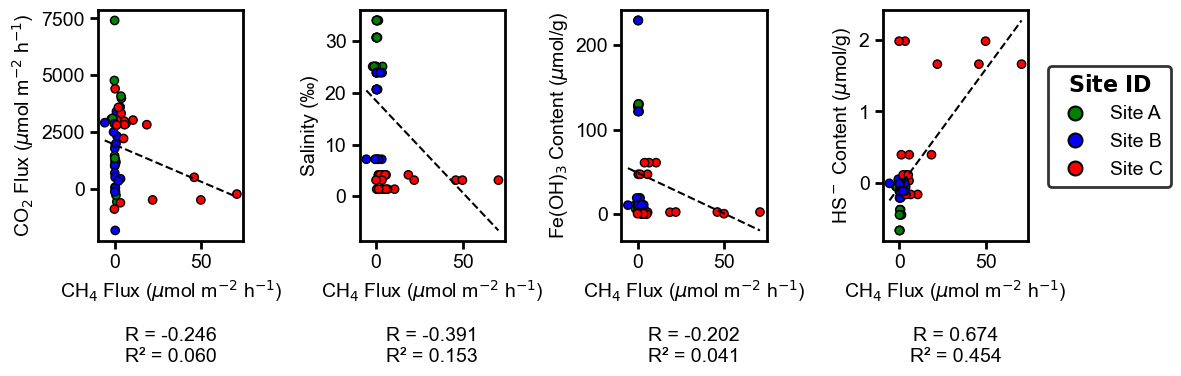

In [18]:
draft = True
df2 = df0.rename(columns={'CO2':'CO$_2$ Flux ($\mu$mol m$^{-2}$ h$^{-1}$)',
                        'CH4':'CH$_4$ Flux ($\mu$mol m$^{-2}$ h$^{-1}$)',
                        'Fe(OH)3':'Fe(OH)$_3$ Content ($\mu$mol/g)',
                        'HS-':'HS$^-$ Content ($\mu$mol/g)',
                        'Salinity':'Salinity (\u2030)'
                         })

regress_cols = [3,7,10,11]
col_interest = [4]

point_colours = df['Site'].map(colour_dict)

scattercompare(df2,df2.columns[col_interest],df2.columns[regress_cols], color=point_colours)

# Fig. 3 Analyses and Plot

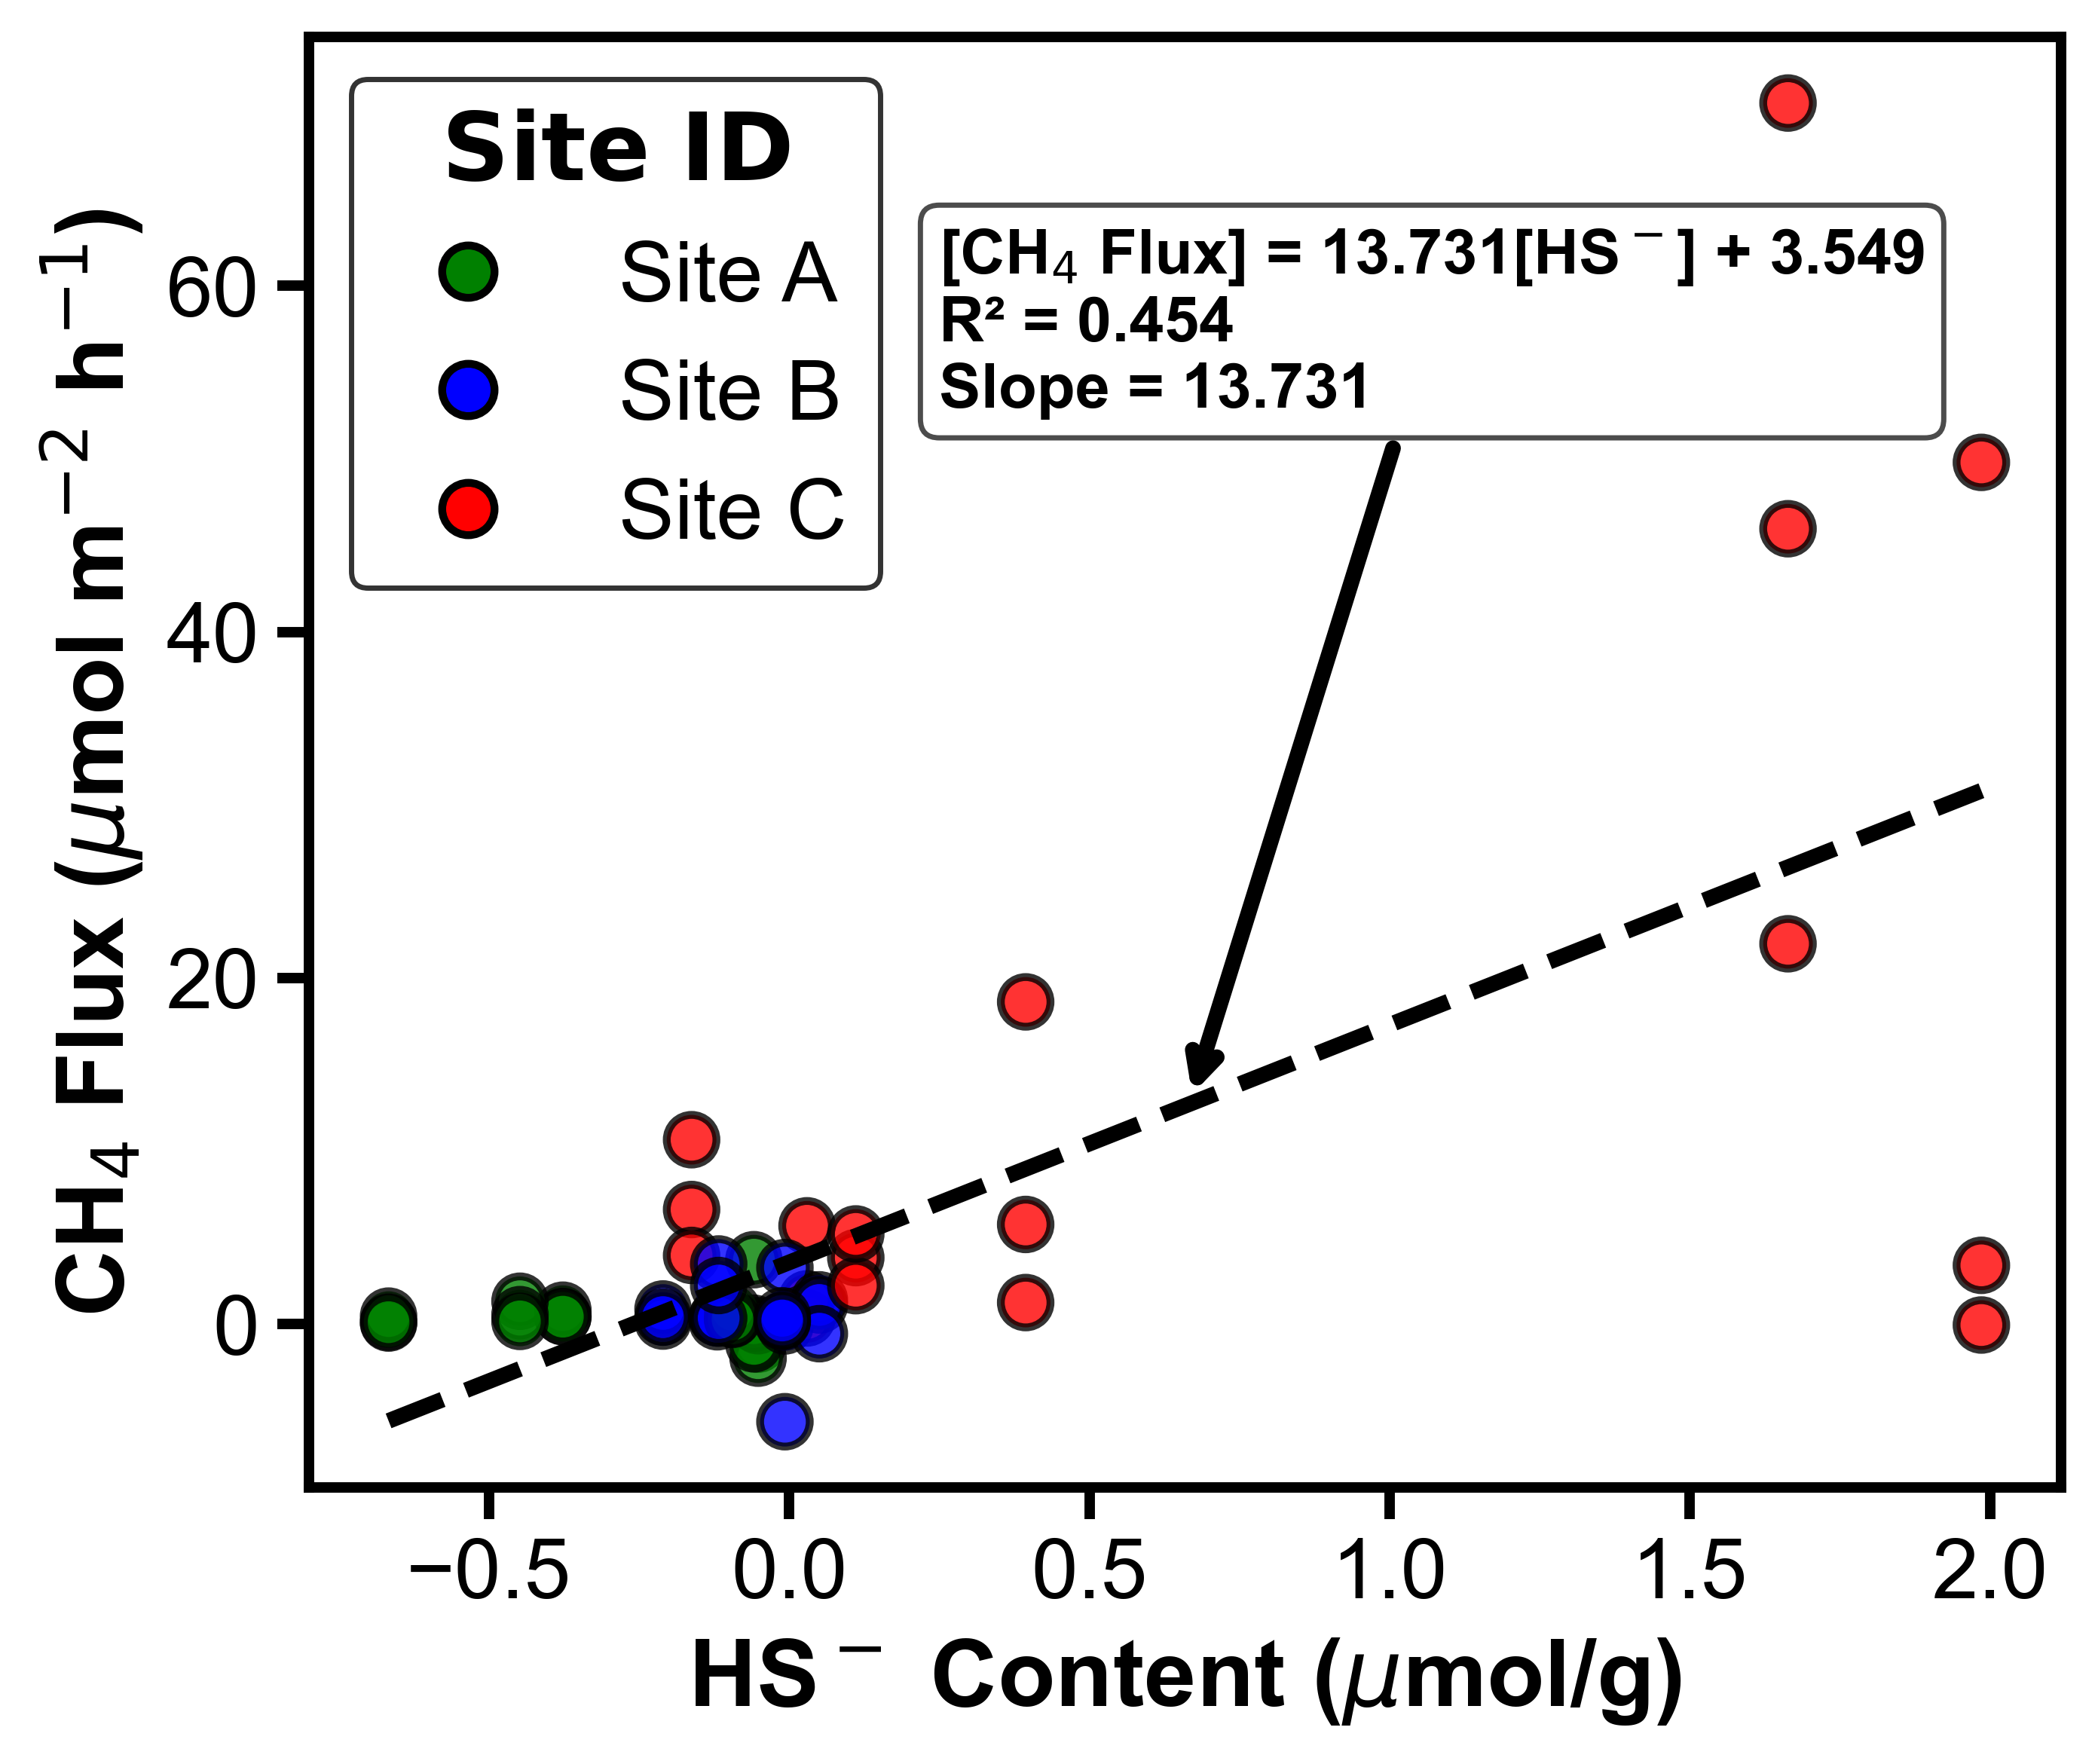

In [5]:
point_colours = df0['Site'].map(colour_dict)
draft = True

fig, ax = plt.subplots(figsize=(6,5))
methane = df0['CH4']
HS = df0['HS-']

ax.scatter(HS, methane, color=point_colours, s=90, marker='o', linewidths=1.5, edgecolors='black', alpha=0.8)

slope, intercept, r_value, p_value, std_err = stats.linregress(HS,methane)
r_squared = r_value**2

x_lin = np.linspace(HS.min(), HS.max(), 200)
y_lin = slope * x_lin + intercept
ax.plot(x_lin, y_lin, color='black', linewidth=3, linestyle='--')

sign = '+' if intercept >=0 else '-'
equation = f'[CH$_4$ Flux] = {slope:.3f}[HS$^-$] {sign} {abs(intercept):.3f}\nR² = {r_squared:.3f}\nSlope = {slope:.3f}'

mid_x = x_lin[len(x_lin)//2]
mid_y = y_lin[len(y_lin)//2]

ax.annotate(equation, xy=(mid_x, mid_y),
            xytext = (0.25,53),
            fontsize=12,
            color='black',
            weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
            arrowprops=dict(arrowstyle='->', color='black', lw=3))

ax.set_ylabel('CH$_4$ Flux ($\mu$mol m$^{-2}$ h$^{-1}$)', fontsize=18, weight='bold')
ax.set_xlabel('HS$^-$ Content ($\mu$mol/g)', fontsize=18, weight='bold')
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6)
for i in ax.spines.values():
    i.set_linewidth(2)

site_leg = [Line2D([0],[0], marker='o', color='w', markersize=10, markerfacecolor='green', markeredgecolor='black', markeredgewidth=1.5, label='Site A'),
             Line2D([0],[0], marker='o', color='w', markersize=10, markerfacecolor='blue', markeredgecolor='black', markeredgewidth=1.5, label='Site B'),
             Line2D([0],[0], marker='o', color='w', markersize=10, markerfacecolor='red', markeredgecolor='black', markeredgewidth=1.5, label='Site C')]
ax.legend(handles=site_leg, title=r"$\bf{Site \ ID}$", title_fontsize=18, fontsize=16, frameon=True, edgecolor='black', loc='upper left')

fig.set_dpi(500)
if draft==False:
        plt.savefig('Fig 3.pdf',dpi=500, bbox_inches='tight')
        plt.savefig('Fig 3.png',dpi=500, bbox_inches='tight')